Lex Albrandt  
SYSC410  
Data Adventure 1  

In [1]:
# Imports
from unicodedata import numeric

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer

# Pipeline Step 1: Data loading, inspection, and cleaning
  
The first step in our ML pipeline is loading the csv file using the `pandas` library. 
We will also output the first 5 rows of data to inspect. 

In [2]:
df = pd.read_csv('../data/skyserver_classroom.csv')
print(df.head())
print(f"\nData Rows and Columns: {df.shape}")

    class  redshift     mag_u     mag_g     mag_r     mag_i     mag_z  \
0    STAR -0.000426  21.14086  20.16528  19.69889  19.51624  19.52510   
1    STAR  0.000388  24.93039  23.32141  21.01002  20.01553  19.49703   
2  GALAXY  0.102577  19.14357  17.76328  17.13229  16.74271  16.48668   
3  GALAXY  0.121415  19.87450  18.51950  17.75688  17.37121  17.06570   
4  GALAXY  0.386381  23.68880  21.90990  19.83497  19.15776  18.68194   

           ra        dec      u_g      g_r      r_i      i_z  
0  300.699820 -11.040715  0.97558  0.46639  0.18265 -0.00886  
1  183.448240  26.267395  1.60898  2.31139  0.99449  0.51850  
2  147.181740  47.056300  1.38029  0.63099  0.38958  0.25603  
3  166.036710   9.333010  1.35500  0.76262  0.38567  0.30551  
4   20.664444  26.167840  1.77890  2.07493  0.67721  0.47582  

Data Rows and Columns: (1500, 13)


From the output above we can see that our dataset has 1500 rows and 13 columns. 
The columns of our data are as follows:  
- ID
  - Object ID
- Class
   - Object Class
- Redshift
  - Measures how much light from an object has been stretched due to the 
expansion of the universe
- mag_u
  - Ultraviolet wavelength magnitude
- mag_g
  - Green wavelength magnitude
- mag_r
  - Red wavelength magnitude
- mag_i
  - Near-infrared wavelength magnitude
- mag_z
  - Infrared wavelength magnitude
- ra
  - Right Ascension: horizontal position in degrees
- dec
  - Declination: vertical position in degrees
- u_g
  - $\text{u\_g} = \text{mag\_u} - \text{mag\_g}$
  - Color index between $u$ and $g$ bands
- g_r
  - $\text{g\_r} = \text{mag\_g} - \text{mag\_r}$
  - Color index between $g$ and $r$ bands
- r_i
  - $\text{r\_i} = \text{mag\_r} - \text{mag\_i}$
  - Color index between $r$ and $i$ bands
- i_z
  - $\text{i\_z} = \text{mag\_i} - \text{mag\_z}$
  - Color index between $i$ and $z$ bands
  
There are also 3 classes in this dataset: Star, Galaxy, and QSO (quasar).  

Now we want to check for missing values.

In [3]:
missing_count = df.isna().sum()
print(missing_count)

class       0
redshift    0
mag_u       0
mag_g       0
mag_r       0
mag_i       0
mag_z       0
ra          0
dec         0
u_g         0
g_r         0
r_i         0
i_z         0
dtype: int64


Based on the output above there are no missing values in the dataset. However, 
we will also use the `SimpleImputer` method from `sklearn` to impute any missing 
values.

In [4]:
numeric_cols = ["ra", 
                "mag_u", 
                "mag_g", 
                "mag_r", 
                "mag_i", 
                "mag_z", 
                "dec", 
                "redshift", 
                "u_g", 
                "g_r", 
                "r_i", 
                "i_z"]

imputer = SimpleImputer(strategy = "median")
df[numeric_cols] = imputer.fit_transform(df[numeric_cols])
df = df.dropna()
print(f"Rows after imputation and cleanup: {len(df)}")

# # Pipeline Step 2: Explore
#   
#

Rows after imputation and cleanup: 1500


From the graph above we can see that all classes have equal distribution. So our 
dataset is balanced. The next step in the exploration process is to see if we can 
find any features that separate the classes. We can do this using `pariplot` from 
the `seaborn` library. Since the pairplot is so large with all feature columns, 
we will break it up into a few different pairplots to better visualize the data.  
In the lines below we have separated the data into three subsets of our original 
dataframe.   
  
  
## Correlation matrix  
  

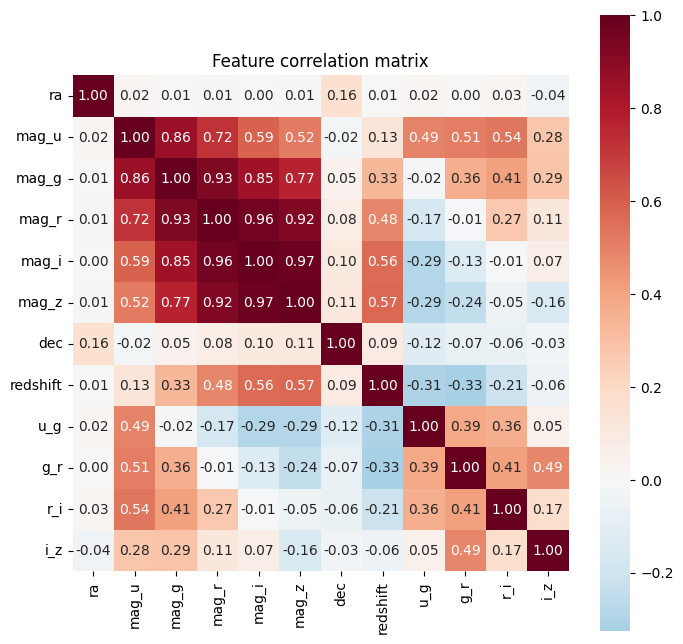

In [5]:
# All columns are already numeric columns
corr = df[numeric_cols].corr()
plt.figure(figsize = (8, 8))
sns.heatmap(corr, annot = True, fmt = "0.2f", cmap = "RdBu_r", center = 0, square = True)
plt.title("Feature correlation matrix")
plt.show()

The correlation matrix above shows a high correlation between all of the wavelength 
magnitudes. We can make a correlation matrix that uses a subset to get a better 
view those correlations.

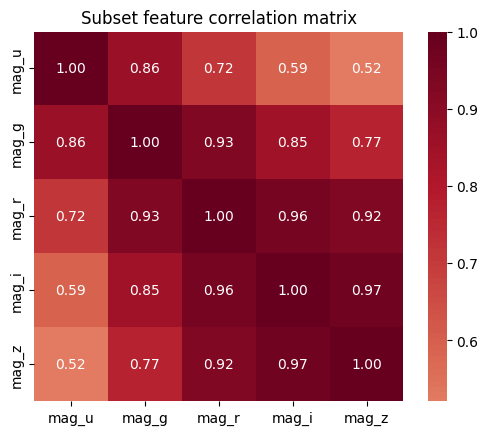

In [6]:
features = df[["mag_u", "mag_g", "mag_r", "mag_i", "mag_z"]]
corr_2 = features.corr()
sns.heatmap(corr_2, annot = True, fmt = "0.2f", cmap = "RdBu_r", center = 0, square = True)
plt.title("Subset feature correlation matrix")
plt.show()

Based on the two correlation matrices and our pairplot, it is reasonable at this 
point in the exploration to drop the magnitude columns, and the `ra` and `dec` 
columns. The magnitude columns can be dropped because of high correlation, and 
`ra` and `dec` can be dropped because they are _positional_ values, and do not 
aid us in classification. We can look at using PCA later if we decide to use 
any of the magnitude columns for classifcation or regression.
  

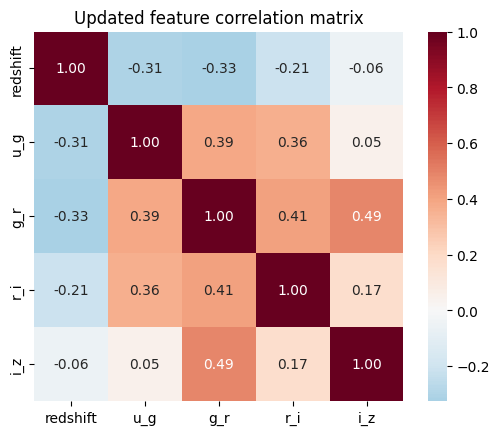

In [7]:
# Update X-feat
X_feat = df[["redshift", "u_g", "g_r", "r_i", "i_z"]]

# Updated correlation matrix
corr_3 = X_feat.corr()
sns.heatmap(corr_3, annot = True, fmt = "0.2f", cmap = "RdBu_r", center = 0, square = True)
plt.title("Updated feature correlation matrix")
plt.show()

## 